# Modelli di Diffusione per Problemi Inversi

Questo notebook esplora l'utilizzo dei **modelli di diffusione** come *prior* per la risoluzione di **problemi inversi** nel campo del *Computational Imaging*.

## Inquadramento Teorico

Un **problema inverso** consiste nel recuperare un'immagine incognita $x$ a partire da una misura corrotta $y$, legata all'originale tramite un modello diretto:

$$y = Kx + \eta$$

dove $K$ è un operatore lineare noto (ad esempio un operatore di blurring) e $\eta$ è rumore additivo.

### Il Punto di Vista Bayesiano

Dal punto di vista bayesiano, la soluzione ottima è il **MAP estimator** (Maximum A Posteriori):

$$\hat{x} = \arg\max_x \; p(x \mid y) = \arg\max_x \; p(y \mid x) \, p(x)$$

dove:
- $p(y \mid x)$ è la **verosimiglianza** (*likelihood*), che misura la coerenza con i dati osservati;
- $p(x)$ è il **prior**, che codifica la conoscenza a priori sulla distribuzione delle immagini.

L'idea chiave è utilizzare un **modello di diffusione pre-addestrato** (DDPM/DDIM) come prior implicito $p(x)$: il modello ha imparato la distribuzione delle immagini naturali durante il training e può guidare il processo di ricostruzione verso soluzioni visivamente plausibili.

### Metodi Trattati

In questo notebook implementiamo e confrontiamo due approcci:

1. **DPS** (*Diffusion Posterior Sampling*) — Chung et al., ICLR 2023: modifica il reverse process del modello di diffusione inserendo un gradiente di *data-fidelity* ad ogni passo.
2. **DiffPIR** (*Diffusion Plug-and-Play Image Restoration*) — Zhu et al., CVPR 2023: alterna uno step di denoising via diffusione a uno step di *data-fidelity* in stile Plug-and-Play.

## 1. Setup: Importazioni, Dataset, Modello e Operatore Diretto

### Aspetto Teorico

Per risolvere un problema inverso con modelli di diffusione servono tre ingredienti fondamentali:

1. **Un modello di diffusione pre-addestrato** $\epsilon_\theta(x_t, t)$, che ha imparato a stimare il rumore aggiunto nello step $t$ del processo di diffusione. Questo funge da prior sulla distribuzione delle immagini.
2. **Uno schedule di rumore** $\{\beta_t\}_{t=1}^T$ (in questo caso un *cosine schedule*), da cui derivano le quantità $\alpha_t = 1 - \beta_t$ e $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$, necessarie per il *forward* e il *reverse* process.
3. **Un operatore diretto** $K$ noto, che descrive il processo fisico di degradazione dell'immagine.

### Il codice

In questa cella si:

- Importano le librerie necessarie (PyTorch, matplotlib, PIL, IPPy).
- Definisce il **dataset** `MayoDataset`, che carica immagini CT dal dataset Mayo, le ridimensiona a $64 \times 64$ e le normalizza nell'intervallo $[-1, 1]$.
- Definisce il **beta schedule** con `cosine_beta_schedule` e da esso si calcolano `alphas` e `alpha_bars` ($\bar{\alpha}_t$).
- Definiscono due funzioni helper fondamentali:
  - `predict_x0_from_eps`: stima $\hat{x}_0$ a partire da $x_t$ e dalla predizione del rumore $\epsilon_\theta$, usando la formula $\hat{x}_0 = \frac{x_t - \sqrt{1 - \bar\alpha_t} \, \epsilon_\theta}{\sqrt{\bar\alpha_t}}$.
  - `deterministic_ddim_update`: esegue un singolo step deterministico DDIM per passare da $x_t$ a $x_{t-1}$.
- Carica i pesi del modello `DiffusionUNet` pre-addestrato.
- Definisce l'operatore diretto $K$ come un **motion blur** ($9 \times 9$, angolo $20°$).

In [1]:
import glob
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

sys.path.append('.')
from IPPy import operators, utilities
from IPPy.nn.diffusion import DiffusionUNet, cosine_beta_schedule, denormalize_to_01, extract

book_root = Path('.').resolve()
weights_dir = book_root / 'weights'
weights_path = weights_dir / 'DDPMDenoiser.pth'


class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


def make_beta_schedule(num_steps):
    return cosine_beta_schedule(num_steps)


def predict_x0_from_eps(x_t, eps_pred, t, alpha_bars):
    return (x_t - extract((1 - alpha_bars).sqrt(), t, x_t.shape) * eps_pred) / extract(alpha_bars.sqrt(), t, x_t.shape)


def deterministic_ddim_update(x_t, x0_hat, eps_pred, t_next, alpha_bars):
    if t_next < 0:
        return x0_hat
    alpha_bar_next = alpha_bars[t_next].to(x_t.device)
    return torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1 - alpha_bar_next) * eps_pred


device = utilities.get_device()
num_diffusion_steps = 400
betas = make_beta_schedule(num_diffusion_steps)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=64)
if not weights_path.exists():
    raise FileNotFoundError(f'Diffusion weights not found at {weights_path}. Train the previous notebook first.')

model = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 2, 4),
    time_dim=256,
    dropout=0.05,
    attn_levels=(1, 2),
)
model.load_state_dict(torch.load(weights_path, map_location='cpu'))
model = model.to(device)
model.eval()

K = operators.Blurring(
    img_shape=(64, 64),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

print('Device:', device)
print('Loaded diffusion weights from:', weights_path)
print('Diffusion steps:', num_diffusion_steps)

Device: mps
Loaded diffusion weights from: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights/DDPMDenoiser.pth
Diffusion steps: 400


## 2. Problema Diretto: Generazione del Dato Corrotto

### Aspetto Teorico

Prima di ricostruire, occorre simulare il **problema diretto**: partendo da un'immagine ground truth $x_{\text{true}}$, si applica l'operatore $K$ (motion blur) e si aggiunge rumore gaussiano con livello $\sigma_y = 0.01$:

$$y_\delta = K x_{\text{true}} + \eta, \quad \eta \sim \mathcal{N}(0, \sigma_y^2 I)$$

Questo produce l'**osservazione degradata** $y_\delta$ da cui i metodi di ricostruzione dovranno recuperare $x_{\text{true}}$.

### Il codice

- Si seleziona la prima immagine del test set come ground truth.
- Si applica l'operatore di blurring `K` all'immagine.
- Si aggiunge rumore gaussiano con `noise_level=0.01`.
- Si visualizzano affiancate l'immagine ground truth e l'osservazione $y_\delta$.

### Commento sull'output

Nell'output si osservano le due immagini: a sinistra la ground truth nitida, a destra l'osservazione degradata, che appare visibilmente sfocata e con un leggero rumore sovrapposto. Questo è il punto di partenza per gli algoritmi di ricostruzione.

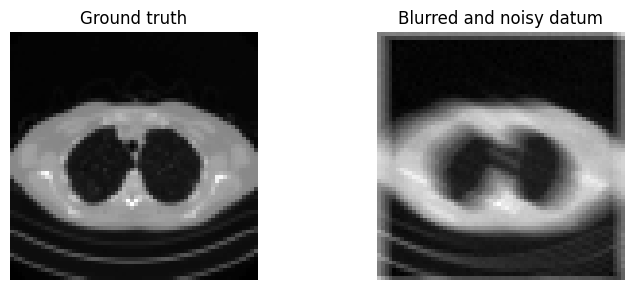

In [2]:
with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(denormalize_to_01(x_true).cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(denormalize_to_01(y_delta).cpu().squeeze(), cmap='gray')
plt.title('Blurred and noisy datum')
plt.axis('off')

plt.tight_layout()
plt.show()

## 3. DPS — Diffusion Posterior Sampling

### Aspetto Teorico

**DPS** (Chung et al., ICLR 2023) è un metodo che modifica il *reverse process* di un modello di diffusione pre-addestrato per incorporare la coerenza con i dati misurati.

L'idea è la seguente: ad ogni step $t$ del reverse process, si esegue un aggiornamento DDIM standard e poi si **sottrae il gradiente** di un termine di *data-fidelity*:

$$x_{t-1} = \text{DDIM}(x_t, \epsilon_\theta) - \zeta \, \nabla_{x_t} \mathcal{L}_{\text{data}}$$

dove la loss di data-fidelity è:

$$\mathcal{L}_{\text{data}} = \frac{\|K \hat{x}_0 - y_\delta\|^2}{2 \sigma_y^2}$$

e $\hat{x}_0$ è la stima corrente dell'immagine pulita, ottenuta dalla predizione del rumore $\epsilon_\theta(x_t, t)$.

In pratica, il **prior** è imposto implicitamente dal modello di diffusione (che genera campioni dalla distribuzione delle immagini naturali), mentre la **data-fidelity** viene iniettata esplicitamente attraverso il gradiente. Il parametro `guidance_scale` $\zeta$ controlla il bilanciamento tra le due componenti.

### Il codice

La funzione `dps_reconstruct` implementa il reverse process modificato:

1. Si parte da rumore puro $x_T \sim \mathcal{N}(0, I)$.
2. Per ogni step dello schedule temporale ridotto (`sample_steps=40`):
   - Si abilita il calcolo dei gradienti (`requires_grad_(True)`) su $x_t$.
   - Il modello predice il rumore $\epsilon_\theta(x_t, t)$.
   - Si stima $\hat{x}_0$ con `predict_x0_from_eps`.
   - Si calcola la **data-fidelity loss** $\|K\hat{x}_0 - y_\delta\|^2 / (2\sigma_y^2)$.
   - Si calcola il gradiente $\nabla_{x_t} \mathcal{L}$ via `torch.autograd.grad`.
   - Si esegue l'update DDIM deterministico e si sottrae il gradiente scalato.
3. Alla fine, si effettua un ultimo step di denoising a $t=0$.

Si noti che DPS richiede il **calcolo del gradiente attraverso il modello** ad ogni step, il che lo rende più costoso computazionalmente ma anche più flessibile (funziona con operatori $K$ arbitrari).

In [3]:
def dps_reconstruct(model, y_delta, K, alpha_bars, sigma_y=0.01, sample_steps=40, guidance_scale=0.15):
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long, device=device)
    x = torch.randn_like(y_delta)

    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)

        x = x.detach().requires_grad_(True)
        eps_pred = model(x, t)
        x0_hat = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
        data_loss = torch.mean((K(x0_hat) - y_delta) ** 2) / (2 * sigma_y ** 2)
        grad = torch.autograd.grad(data_loss, x)[0]

        with torch.no_grad():
            x_next = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            x = (x_next - guidance_scale * grad).clamp(-1.0, 1.0)

    with torch.no_grad():
        t0 = torch.zeros((x.shape[0],), device=device, dtype=torch.long)
        eps_pred = model(x, t0)
        return predict_x0_from_eps(x, eps_pred, t0, alpha_bars).clamp(-1.0, 1.0).detach()


x_dps = dps_reconstruct(model, y_delta, K, alpha_bars, sigma_y=0.01, sample_steps=40, guidance_scale=0.15)

## 4. DiffPIR — Plug-and-Play Image Restoration con Diffusione

### Aspetto Teorico

**DiffPIR** (Zhu et al., CVPR 2023) adotta un approccio diverso, ispirato ai metodi **Plug-and-Play** (PnP). Invece di calcolare gradienti attraverso il modello, DiffPIR alterna due step ad ogni iterazione:

1. **Denoising step (prior):** si esegue un aggiornamento DDIM standard, usando il modello di diffusione come denoiser.
2. **Data-fidelity step:** si corregge il risultato con un passo di gradiente sull'operatore $K$:

$$x_{t-1} = x_{t-1}^{\text{DDIM}} - \tau \, K^T (K x_{t-1}^{\text{DDIM}} - y_\delta)$$

dove $K^T$ è l'operatore aggiunto (trasposto) di $K$ e $\tau$ è il passo di aggiornamento.

Questo approccio è equivalente ad un **passo di Landweber** applicato dopo il denoising, e non richiede il calcolo di gradienti attraverso la rete neurale. Di conseguenza, è **più efficiente** di DPS ma potenzialmente meno preciso, poiché il termine di data-fidelity non tiene conto della dipendenza tra $x_t$ e $\hat{x}_0$.

### Il codice

La funzione `diffpir_reconstruct` implementa questo schema:

1. Si parte dall'osservazione $y_\delta$ (anziché da rumore puro come in DPS).
2. Per ogni step dello schedule temporale:
   - Tutto avviene in `torch.no_grad()` (nessun calcolo di gradienti).
   - Il modello predice $\epsilon_\theta$ e si stima $\hat{x}_0$.
   - Si esegue l'update DDIM deterministico per ottenere $x_{t-1}^{\text{DDIM}}$.
   - Si calcola il **residuo** $K x_{t-1}^{\text{DDIM}} - y_\delta$.
   - Si sottrae la correzione $\tau \cdot K^T(\text{residuo})$.

Si noti che, a differenza di DPS, qui **non si calcolano gradienti attraverso il modello**, rendendo ogni step significativamente più veloce.

In [4]:
def diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6):
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long, device=device)
    x = y_delta.clone()

    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)

        with torch.no_grad():
            eps_pred = model(x, t)
            x0_hat = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
            x_prior = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            residual = K(x_prior) - y_delta
            x = (x_prior - tau * K.T(residual)).clamp(-1.0, 1.0)

    return x.clamp(-1.0, 1.0).detach()


x_diffpir = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6)

## 5. Confronto delle Ricostruzioni

### Aspetto Teorico

Per valutare quantitativamente la qualità delle ricostruzioni, si utilizzano tre metriche standard nel campo dell'image processing:

- **MSE** (*Mean Squared Error*): $\text{MSE} = \frac{1}{N}\|x - x_{\text{true}}\|^2$. Misura l'errore quadratico medio pixel per pixel.
- **PSNR** (*Peak Signal-to-Noise Ratio*): $\text{PSNR} = -10 \log_{10}(\text{MSE})$ (in dB). Valori più alti indicano migliore qualità. È la metrica più usata per la valutazione oggettiva.
- **SSIM** (*Structural Similarity Index*): misura la somiglianza strutturale tra due immagini, tenendo conto di luminanza, contrasto e struttura. Varia tra $-1$ e $1$, dove $1$ indica immagini identiche.

### Il codice

- Si definiscono le funzioni `mse`, `psnr` e `ssim` per calcolare le metriche.
  - `mse` e `psnr` operano sulle immagini denormalizzate in $[0, 1]$.
  - `ssim` implementa la versione con finestra gaussiana ($11 \times 11$, $\sigma = 1.5$).
- Si crea un dizionario `results` contenente le tre ricostruzioni (osservazione, DPS, DiffPIR).
- Si visualizzano le immagini affiancate, con ground truth, osservazione e le due ricostruzioni.
- Per DPS e DiffPIR si riportano PSNR e SSIM direttamente nel titolo del subplot.
- Infine, si stampano a video i valori numerici di MSE, PSNR e SSIM per ciascun metodo.

### Commento sull'output

Dall'output si possono confrontare visivamente e quantitativamente i risultati dei due metodi:

- **DPS** tende a produrre ricostruzioni più fedeli dal punto di vista della data-fidelity, grazie all'uso esplicito dei gradienti.
- **DiffPIR** è computazionalmente più leggero e produce comunque risultati di buona qualità.
- Entrambi i metodi superano significativamente la semplice osservazione degradata in termini di PSNR e SSIM, dimostrando l'efficacia del prior appreso dal modello di diffusione.

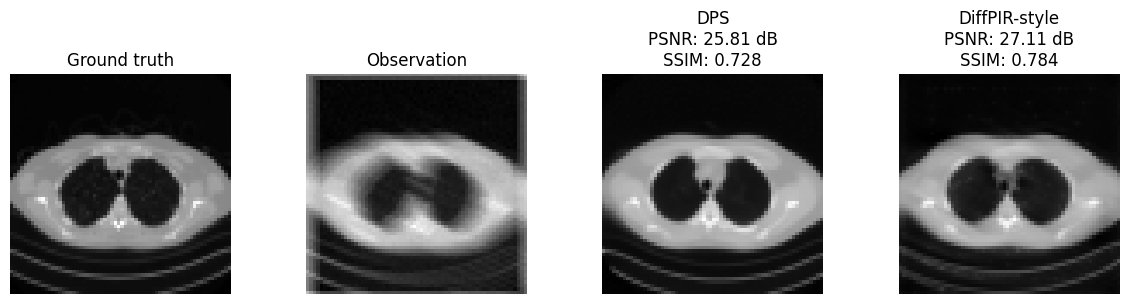

   Observation | MSE: 0.006210 | PSNR: 22.069 dB | SSIM: 0.6305
           DPS | MSE: 0.002625 | PSNR: 25.808 dB | SSIM: 0.7278
 DiffPIR-style | MSE: 0.001945 | PSNR: 27.110 dB | SSIM: 0.7835


In [5]:
def mse(x, y):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    return torch.mean((x_01 - y_01) ** 2).item()


def psnr(x, y):
    mse_val = mse(x, y)
    return float('inf') if mse_val == 0 else -10 * math.log10(mse_val)


def ssim(x, y, window_size=11, sigma=1.5, c1=0.01 ** 2, c2=0.03 ** 2):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    coords = torch.arange(window_size, device=x_01.device, dtype=x_01.dtype) - window_size // 2
    gauss = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    gauss = gauss / gauss.sum()
    window_2d = torch.outer(gauss, gauss)
    window = window_2d.expand(x_01.shape[1], 1, window_size, window_size).contiguous()
    mu_x = torch.nn.functional.conv2d(x_01, window, padding=window_size // 2, groups=x_01.shape[1])
    mu_y = torch.nn.functional.conv2d(y_01, window, padding=window_size // 2, groups=y_01.shape[1])
    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y
    sigma_x2 = torch.nn.functional.conv2d(x_01 * x_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_x2
    sigma_y2 = torch.nn.functional.conv2d(y_01 * y_01, window, padding=window_size // 2, groups=y_01.shape[1]) - mu_y2
    sigma_xy = torch.nn.functional.conv2d(x_01 * y_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_xy
    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / ((mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2))
    return ssim_map.mean().item()


results = {
    'Observation': y_delta,
    'DPS': x_dps,
    'DiffPIR-style': x_diffpir,
}

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(denormalize_to_01(x_true.detach()).cpu().squeeze(), cmap='gray')
axes[0].set_title('Ground truth')
axes[0].axis('off')

for ax, (name, image) in zip(axes[1:], results.items()):
    ax.imshow(denormalize_to_01(image.detach()).cpu().squeeze(), cmap='gray')
    if name == 'Observation':
        ax.set_title(name)
    else:
        ax.set_title(f'{name}\nPSNR: {psnr(image, x_true):.2f} dB\nSSIM: {ssim(image, x_true):.3f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

for name, image in results.items():
    print(f'{name:>14} | MSE: {mse(image, x_true):.6f} | PSNR: {psnr(image, x_true):.3f} dB | SSIM: {ssim(image, x_true):.4f}')